In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv("Titanic_train.csv")
test = pd.read_csv("Titanic_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Missing values in train:\n")
print(train.isnull().sum())

Missing values in train:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Fill missing ages with median age
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

# Fill missing embarked with most common value
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

# Fill missing fare in test
test['Fare'].fillna(test['Fare'].median(), inplace=True)

# Convert gender to numbers (male=0, female=1)
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

print("Missing values after cleaning:")
print(train.isnull().sum())

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


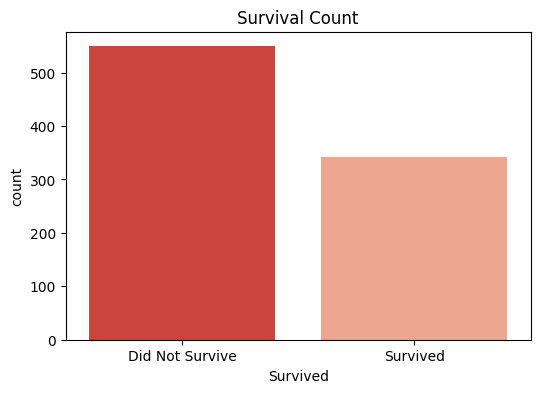

Survival rate: 38.38 %


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Survived', palette='Reds_r')
plt.title('Survival Count')
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.show()

print("Survival rate:", round(train['Survived'].mean() * 100, 2), "%")

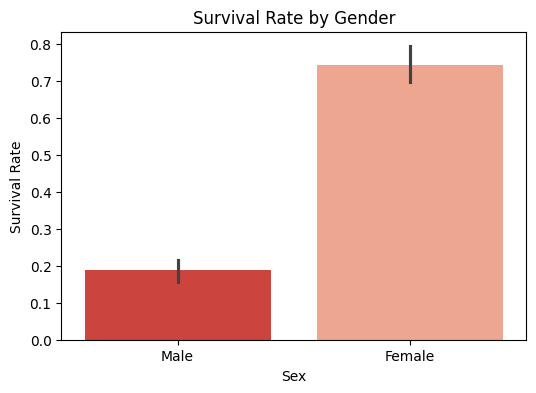

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Sex', y='Survived', palette='Reds_r')
plt.title('Survival Rate by Gender')
plt.xticks([0,1], ['Male', 'Female'])
plt.ylabel('Survival Rate')
plt.show()

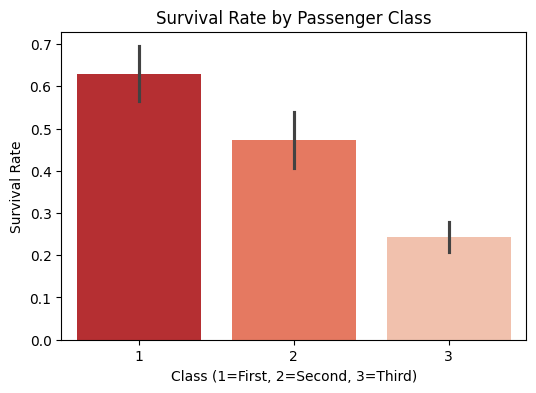

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Pclass', y='Survived', palette='Reds_r')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival Rate')
plt.show()

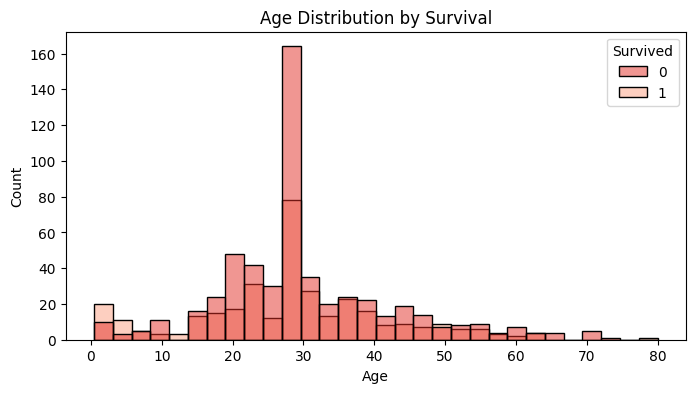

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(data=train, x='Age', hue='Survived', bins=30, palette='Reds_r')
plt.title('Age Distribution by Survival')
plt.show()

In [10]:
# Select features for the model
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

X = train[features]
y = train['Survived']

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Check accuracy
predictions = model.predict(X_val)
accuracy = accuracy_score(y_val, predictions)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 80.45 %


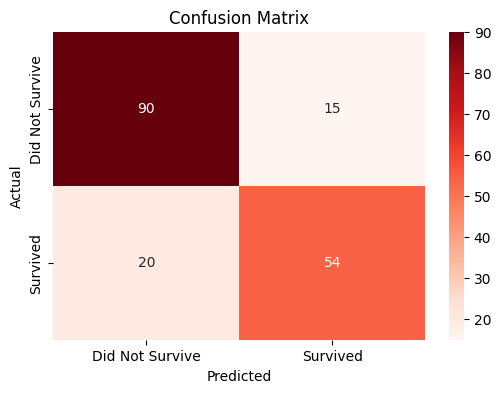

In [11]:
cm = confusion_matrix(y_val, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

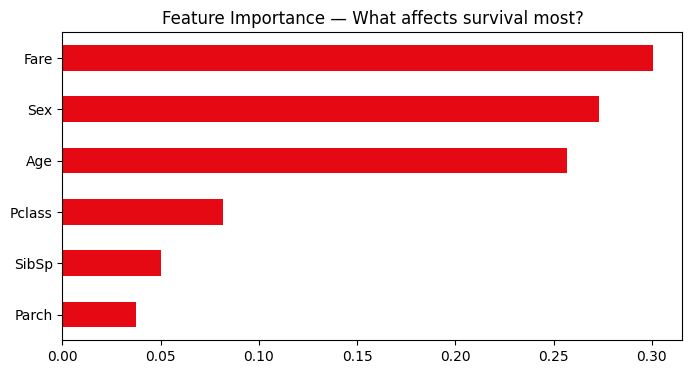

In [12]:
importance = pd.Series(model.feature_importances_, index=features)
plt.figure(figsize=(8,4))
importance.sort_values().plot(kind='barh', color='#E50914')
plt.title('Feature Importance — What affects survival most?')
plt.show()

In [13]:
print("""
TITANIC SURVIVAL PREDICTION - SUMMARY
======================================
Dataset: 891 passengers in training set
Features used: Passenger class, Gender, Age, Family size, Fare
Algorithm: Random Forest (100 trees)
Model Accuracy: {:.2f}%

Key Findings:
- Gender is the strongest predictor of survival
- First class passengers had significantly higher survival rates
- Children had higher survival rates than adults
""".format(accuracy * 100))


TITANIC SURVIVAL PREDICTION - SUMMARY
Dataset: 891 passengers in training set
Features used: Passenger class, Gender, Age, Family size, Fare
Algorithm: Random Forest (100 trees)
Model Accuracy: 80.45%

Key Findings:
- Gender is the strongest predictor of survival
- First class passengers had significantly higher survival rates
- Children had higher survival rates than adults

